In [81]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.cm import get_cmap
from matplotlib.colors import to_hex

def estimate_distance_data_units(p1, p2, s, fig, ax):
    # Calculate the distance from the edge of one point to the edge of the other in display units
    
    # Convert points to display coordinates
    p1_display = ax.transData.transform([p1])[0]
    p2_display = ax.transData.transform([p2])[0]
    
    # Calculate distance between centers in pixels
    distance_pixels = np.sqrt((p2_display[0] - p1_display[0])**2 + 
                              (p2_display[1] - p1_display[1])**2)
    
    # Calculate radius in pixels from s
    radius_points = np.sqrt(s) / 2
    radius_pixels = radius_points * (fig.dpi / 72)
    
    # Distance from edge to edge = distance between centers - 2*radius
    edge_to_edge_pixels = distance_pixels - 2 * radius_pixels
    
    return edge_to_edge_pixels

def check_overlap(pt1_display, pt2_display, target_distance_pixels):
    """
    Fast overlap check using pre-computed display coordinates
    Returns True if gap is violated
    """
    distance_pixels = np.sqrt((pt2_display[0] - pt1_display[0])**2 + 
                              (pt2_display[1] - pt1_display[1])**2)
    return distance_pixels < target_distance_pixels - 1e-6

def calculate_shift_for_new_point(new_pt, new_pt_display, existing_points, 
                                   existing_display_coords, s, gap_fraction, 
                                   fig, ax, target_distance_pixels, 
                                   point_index, verbose_inner=False):
    """
    Optimized version using pre-computed display coordinates
    """
    if verbose_inner:
        print(f"\n{'='*80}")
        print(f"PROCESSING POINT {point_index}: Original position {new_pt}")
        print(f"{'='*80}\n")
    
    # First, check if current position is already valid
    current_is_valid = True
    for i, (idx, row) in enumerate(existing_points.iterrows()):
        existing_pt_display = existing_display_coords[i]
        if check_overlap(new_pt_display, existing_pt_display, target_distance_pixels):
            current_is_valid = False
            break
    
    if current_is_valid:
        if verbose_inner:
            print(f"✓ Current position is valid. No shift needed.\n")
        return 0
    
    if verbose_inner:
        print(f"✗ Current position violates gap. Finding valid positions...\n")
    
    # Calculate radius in pixels
    radius_points = np.sqrt(s) / 2
    radius_pixels = radius_points * (fig.dpi / 72)
    gap_pixels = gap_fraction * 2 * radius_pixels
    
    valid_shifts = []
    
    # Only check closest points (optimization)
    n_existing = len(existing_points)
    check_limit = min(n_existing, 10)  # Only check 10 closest points
    
    # Calculate distances to all existing points
    distances = np.sqrt(np.sum((existing_display_coords - new_pt_display)**2, axis=1))
    closest_indices = np.argsort(distances)[:check_limit]
    
    # For each closest existing point, try to find valid positions
    for array_idx in closest_indices:
        idx = existing_points.index[array_idx]
        row = existing_points.iloc[array_idx]
        existing_pt_display = existing_display_coords[array_idx]
        
        # Calculate dy in display coordinates
        dy_pixels = abs(new_pt_display[1] - existing_pt_display[1])
        
        # Calculate required dx for target distance
        dx_pixels_squared = target_distance_pixels**2 - dy_pixels**2
        
        if dx_pixels_squared < 0:
            continue
        
        dx_pixels = np.sqrt(dx_pixels_squared)
        
        # Try both left and right
        for sign in [1, -1]:
            # Calculate candidate position
            new_pt_candidate_display = np.array([
                existing_pt_display[0] + sign * dx_pixels, 
                new_pt_display[1]
            ])
            new_pt_candidate_data = ax.transData.inverted().transform([new_pt_candidate_display])[0]
            shift_candidate = new_pt_candidate_data[0] - new_pt[0]
            
            # Check if this position is valid (doesn't overlap with other points)
            is_valid = True
            for check_idx in range(len(existing_points)):
                if check_idx == array_idx:
                    continue
                existing_pt2_display = existing_display_coords[check_idx]
                if check_overlap(new_pt_candidate_display, existing_pt2_display, target_distance_pixels):
                    is_valid = False
                    break
            
            if is_valid:
                valid_shifts.append({
                    'shift': shift_candidate,
                    'abs_shift': abs(shift_candidate)
                })
    
    if not valid_shifts:
        if verbose_inner:
            print("\n⚠ Warning: No valid position found!")
        return None
    
    # Pick smallest shift
    valid_shifts.sort(key=lambda x: x['abs_shift'])
    best = valid_shifts[0]
    
    if verbose_inner:
        print(f"✓ CHOSEN: Shift amount: {best['shift']:.4f}\n")
    
    return best['shift']

def position_all_points(x, y, s, gap_fraction, fig, ax, verbose_inner=False):
    """
    Optimized version that pre-computes display coordinates
    """
    # Pre-compute radius in pixels once
    radius_points = np.sqrt(s) / 2
    radius_pixels = radius_points * (fig.dpi / 72)
    gap_pixels = gap_fraction * 2 * radius_pixels
    target_distance_pixels = 2 * radius_pixels + gap_pixels
    
    n_points = len(x)
    
    # Create dataframe with original order and positions
    data = pd.DataFrame({
        'original_index': range(n_points),
        'xorig': x,
        'yorig': y,
        'xnew': [None] * n_points,
        'ynew': [None] * n_points,
        'shift': [None] * n_points
    })
    
    # Sort by y-coordinate
    data = data.sort_values(['yorig', 'xorig']).reset_index(drop=True)
    
    if verbose_inner:
        print(f"\nProcessing {n_points} points...")
    
    # First point stays where it is
    data.loc[0, 'xnew'] = data.loc[0, 'xorig']
    data.loc[0, 'ynew'] = data.loc[0, 'yorig']
    data.loc[0, 'shift'] = 0.0
    
    # Process each subsequent point
    max_shift = 0.0
    for i in range(1, n_points):
        current_pt = (data.loc[i, 'xorig'], data.loc[i, 'yorig'])
        # Transform the CURRENT (unshifted) point to display coordinates
        current_pt_display = ax.transData.transform([current_pt])[0]
        original_idx = data.loc[i, 'original_index']
        
        # Get previously positioned points
        positioned_mask = data['xnew'].notna()
        positioned_so_far = data[positioned_mask].copy()
        
        # Get their display coordinates (updated with shifts)
        positioned_display_coords = []
        for idx, row in positioned_so_far.iterrows():
            shifted_pt = (row['xnew'], row['ynew'])
            shifted_display = ax.transData.transform([shifted_pt])[0]
            positioned_display_coords.append(shifted_display)
        positioned_display_coords = np.array(positioned_display_coords)
        
        # Calculate shift needed
        shift = calculate_shift_for_new_point(
            current_pt, current_pt_display, positioned_so_far, 
            positioned_display_coords, s, gap_fraction, fig, ax, 
            target_distance_pixels, original_idx, verbose_inner
        )
        
        if shift is None:
            return None, None
        
        # Apply shift
        data.loc[i, 'xnew'] = data.loc[i, 'xorig'] + shift
        data.loc[i, 'ynew'] = data.loc[i, 'yorig']
        data.loc[i, 'shift'] = shift
        max_shift = max(max_shift, abs(shift))
    
    # Calculate radius in data units
    origin_display = ax.transData.transform([(0, 0)])[0]
    radius_offset_display = origin_display + np.array([radius_pixels, 0])
    radius_data = ax.transData.inverted().transform([radius_offset_display])[0]
    radius_in_data_units = abs(radius_data[0])
    
    # Maximum extent from original position
    max_shift_and_radius = max_shift + radius_in_data_units
    
    # Sort back to original order
    result = data.sort_values('original_index').reset_index(drop=True)
    result = result[['original_index', 'xorig', 'yorig', 'xnew', 'ynew', 'shift']]
    
    return result, max_shift_and_radius

def find_optimal_s(x, y, gap_fraction, margin, fig, ax, tol=1e-3, N_seq=3, tol_seq=1e-3, 
                   max_iterations=30, verbose_optim_min=False, verbose_optim_full=False, 
                   verbose_inner=False, s_min=100, s_max=10000):
    """
    Optimized version with better defaults
    """
    if verbose_optim_full:
        print(f"\n{'#'*80}")
        print(f"# FINDING OPTIMAL s WITH MARGIN = {margin}")
        print(f"{'#'*80}\n")
    
    best_s = None
    best_result = None
    history = []
    
    seq_errors = []
    best_error = None
    max_seq_error = float('inf')
    iteration = 0
    
    while True:
        iteration += 1
        s_test = (s_min + s_max) / 2

        if verbose_optim_min:
            print(f"Iteration {iteration}: Testing s = {s_test:.1f}.", end=" ")

        # Use optimized positioning
        result, max_shift_and_radius = position_all_points(
            x, y, s_test, gap_fraction, fig, ax, verbose_inner=verbose_inner
        )
        
        max_shift = None
        if result is not None and 'shift' in result.columns:
            try:
                max_shift = float(result['shift'].abs().max())
            except Exception:
                max_shift = None

        if result is None:
            valid = False
            if verbose_optim_min:
                print(f"❌ FAILED")
            s_max = s_test
        elif max_shift_and_radius > margin:
            valid = False
            if verbose_optim_min:
                print(f"❌ FAILED: Max extent = {max_shift_and_radius:.4f} > {margin:.4f}")
            s_max = s_test
        else:
            valid = True
            if verbose_optim_min:
                print(f"✅ SUCCESS: Max extent = {max_shift_and_radius:.4f}")
            best_s = s_test
            best_result = result
            s_min = s_test
    
        error = abs(margin - max_shift_and_radius) if max_shift_and_radius is not None else float('inf')
        if best_error is None or (error < best_error and valid):
            best_error = error
            seq_errors.append(error)
            if len(seq_errors) > N_seq:
                seq_errors = seq_errors[-N_seq:]
                seq_error_diff = [val - seq_errors[-1] for val in seq_errors[:-1]]
                max_seq_error = np.max(np.abs(seq_error_diff))

        history.append({
            'iteration': iteration,
            's_test': s_test,
            'error': error,
            'max_seq_error': max_seq_error,
            'valid': valid,
            'max_shift_and_radius': max_shift_and_radius,
            'max_shift': max_shift
        })
        
        # Stopping conditions
        if iteration >= max_iterations:
            break
        if error < tol and valid:
            break
        if max_seq_error < tol_seq and iteration > 10:
            break

    if best_s is None:
        print(f"\n⚠️  WARNING: Could not find valid s within range [{s_min:.1f}, {s_max:.1f}].")
        print(f"Trying with minimum s = {s_min:.1f}...")
        best_s = s_min
        best_result, best_extent = position_all_points(x, y, best_s, gap_fraction, fig, ax, verbose_inner=False)
        
        # If even minimum s fails, return empty result
        if best_result is None:
            print(f"❌ ERROR: Cannot position points even with minimum s = {s_min:.1f}")
            print(f"Try: increasing margin, decreasing gap_fraction, or decreasing s_min")
            # Return a dummy result so plotting doesn't crash
            n = len(x)
            best_result = pd.DataFrame({
                'original_index': range(n),
                'xorig': x,
                'yorig': y,
                'xnew': x,  # Just use original positions
                'ynew': y,
                'shift': np.zeros(n)
            })
            best_extent = 0
    else:
        if verbose_optim_full:
            print(f"\n{'#'*80}")
            print(f"# OPTIMAL s FOUND: {best_s:.1f}")
            print(f"{'#'*80}\n")
        
        final_result, best_extent = position_all_points(x, y, best_s, gap_fraction, fig, ax, verbose_inner=verbose_inner)
        if final_result is not None:
            best_result = final_result
    
    return best_s, best_result, best_extent, history

def idd_beeswarm(data, x_var, y_var, color_var, color_dict, x_var_order=None, ax=None, fig=None, 
                 fig_size=(8,8), ylim=None, ylim_stretch=0.2, gap_fraction=0.1, margin=0.5, 
                 x_edge_pad=0.5, tol=1e-3, N_seq=3, tol_seq=1e-3, max_iterations=30,
                 draw_margin=False, verbose_optim_min=False, verbose_optim_full=False, 
                 verbose_inner=False, s_min=100, s_max=10000):
    """
    Optimized version with better default parameters
    """
    # Handle figure and axis creation
    if ax is None:
        fig, ax = plt.subplots(figsize=fig_size)
        show_plot = True
    else:
        show_plot = False
        if fig is None:
            fig = ax.get_figure()

    # Extract x and y data
    y = data[y_var].values
    if x_var_order is None:
        x_var_order = data[x_var].unique()
    x_mapping = {val: idx for idx, val in enumerate(x_var_order)}
    x = data[x_var].map(x_mapping).values

    # Set y-limits
    if ylim is not None:
        ax.set_ylim(ylim)
    else:
        y_diff = max(y) - min(y)
        ax.set_ylim(min(y) - ylim_stretch * y_diff, max(y) + ylim_stretch * y_diff)
    ax.set_xlim(min(x) - margin - x_edge_pad, max(x) + margin + x_edge_pad)

    # Find optimal s with optimized algorithm
    optimal_s, final_positions, max_extent, history = find_optimal_s(
        x, y, gap_fraction, margin, fig, ax,
        tol=tol, N_seq=N_seq, tol_seq=tol_seq, max_iterations=max_iterations,
        verbose_optim_min=verbose_optim_min,
        verbose_optim_full=verbose_optim_full,
        verbose_inner=verbose_inner,
        s_min=s_min, s_max=s_max
    )

    final_data = data.join(final_positions[['xnew', 'ynew']])

    # Draw margin lines
    if draw_margin:
        unique_x = sorted(set(x))
        for x_pos in unique_x:
            ax.axvline(x=x_pos - margin, color='gray', linestyle=':', linewidth=2)
            ax.axvline(x=x_pos + margin, color='gray', linestyle=':', linewidth=2)
            ax.axvline(x=x_pos, color='gray', linestyle='-', linewidth=0.5, alpha=0.3)

    # Plot final positions
    for i, row in final_data.iterrows():
        color = color_dict[row[color_var]]
        ax.scatter([row['xnew']], [row['ynew']], s=optimal_s, 
                  edgecolors=None, facecolors=color, marker='o', linewidths=2)

    ax.set_xticks(list(x_mapping.values()))
    ax.set_xticklabels(list(x_mapping.keys()))
    ax.set_xlabel('')

    if show_plot:
        plt.show()
    
    return ax    


Processing 20 points...

PROCESSING POINT 11: Original position (np.int64(1), np.float64(-2.3333333333333335))

✓ Current position is valid. No shift needed.


PROCESSING POINT 12: Original position (np.int64(1), np.float64(-1.6666666666666667))

✓ Current position is valid. No shift needed.


PROCESSING POINT 13: Original position (np.int64(1), np.float64(-1.0))

✓ Current position is valid. No shift needed.


PROCESSING POINT 14: Original position (np.int64(1), np.float64(-0.3333333333333335))

✓ Current position is valid. No shift needed.


PROCESSING POINT 15: Original position (np.int64(1), np.float64(0.33333333333333304))

✓ Current position is valid. No shift needed.


PROCESSING POINT 0: Original position (np.int64(0), np.float64(1.0))

✓ Current position is valid. No shift needed.


PROCESSING POINT 1: Original position (np.int64(0), np.float64(1.0))

✗ Current position violates gap. Finding valid positions...

✓ CHOSEN: Shift amount: 0.0224


PROCESSING POINT 2: Original pos

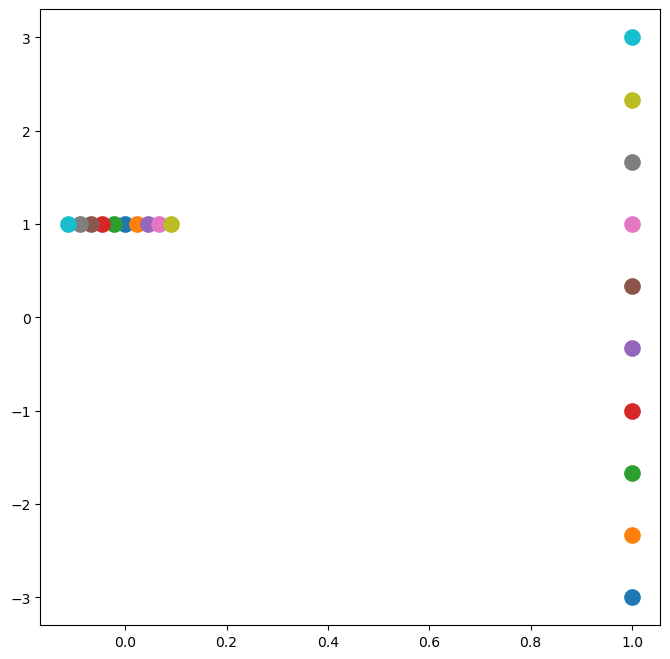

In [86]:
n_obs = 100
d1 = np.random.uniform(low=-3, high=3, size=n_obs)
d2 = np.random.normal(size=n_obs)
n_obs = 10
d1 = np.repeat(1,n_obs)
d2 = np.linspace(-3,3,n_obs)
x = np.concatenate([np.repeat(0, len(d1)), np.repeat(1, len(d2))])
y = np.concatenate([d1, d2])
fig_size = (8,8)

s = 100
fig, ax = plt.subplots(figsize=fig_size)
result, max_shift_and_radius = position_all_points(x=x, y=y, s=s, gap_fraction=0, fig=fig, ax=ax, verbose_inner=True)
for i, row in result.iterrows():
        ax.scatter([row['xnew']], [row['ynew']], s=s, 
                  marker='o', linewidths=2)
plt.show()

In [76]:
y

array([ 1.61903606, -0.19336576,  2.0943083 , -0.99669818, -1.74583262,
        2.15959487, -2.15950944,  0.16846219,  0.06641846,  2.24565768,
       -1.76276585,  2.82104781,  0.82638037,  2.71570705,  1.72225681,
        2.49131585,  0.74504429,  1.93283299, -1.82009018,  2.57885005,
        1.13869698,  2.56308734,  2.23838843,  0.50505168,  2.76788703,
        0.08108291, -1.13445152,  1.59943469, -0.25672726, -1.7819663 ,
        1.08787319,  0.26724022,  0.96753183,  2.94256486, -1.72596747,
       -1.22689051, -2.29339953,  0.96000387, -1.19366704, -2.14721267,
       -0.73411575,  2.10214888, -2.53971164,  1.98354385,  2.25867403,
       -1.80130828, -1.73409781,  1.91593632, -1.39116419,  2.87746713,
        1.73025017, -2.42317726, -1.48632481, -2.56966943, -2.02043736,
       -1.76177628,  0.4905632 ,  1.64466831, -2.64672863, -1.87764932,
        1.61560427,  1.9953919 ,  0.22820433, -2.1413108 ,  2.19765446,
        0.90844584,  0.43452884,  2.66841258, -1.54844525,  0.74

Iteration 1: Testing s = 502.0. ❌ FAILED
Iteration 2: Testing s = 253.0. ❌ FAILED
Iteration 3: Testing s = 128.5. ❌ FAILED
Iteration 4: Testing s = 66.2. ❌ FAILED
Iteration 5: Testing s = 35.1. ✅ SUCCESS: Max extent = 0.1289
Iteration 6: Testing s = 50.7. ✅ SUCCESS: Max extent = 0.1969
Iteration 7: Testing s = 58.5. ❌ FAILED
Iteration 8: Testing s = 54.6. ❌ FAILED
Iteration 9: Testing s = 52.6. ✅ SUCCESS: Max extent = 0.2010
Iteration 10: Testing s = 53.6. ✅ SUCCESS: Max extent = 0.2031
Iteration 11: Testing s = 54.1. ✅ SUCCESS: Max extent = 0.2041
Iteration 12: Testing s = 54.3. ❌ FAILED
Iteration 13: Testing s = 54.2. ✅ SUCCESS: Max extent = 0.2043
Iteration 14: Testing s = 54.3. ❌ FAILED
Iteration 15: Testing s = 54.2. ✅ SUCCESS: Max extent = 0.2044


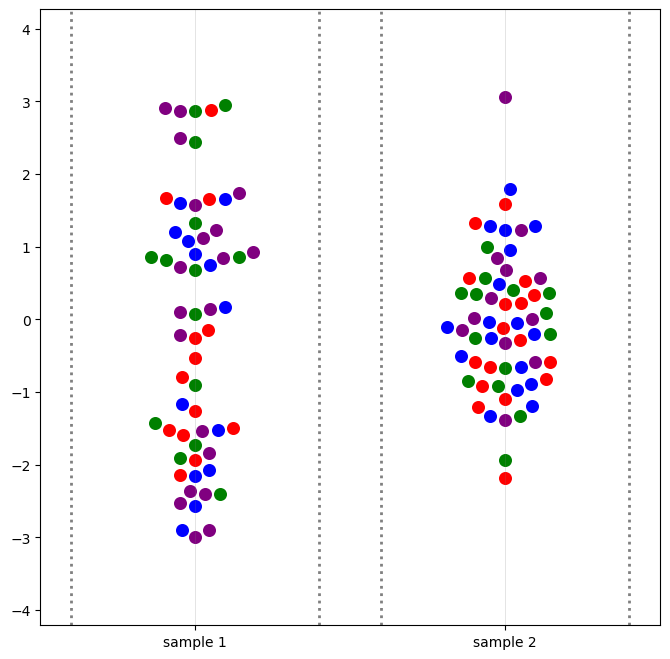

<Axes: >

In [96]:
n_obs = 60
# Generate data
d1 = np.random.uniform(low=-3, high=3, size=n_obs)
d2 = np.random.normal(size=n_obs)
data = pd.DataFrame({
    'location': np.concatenate([np.repeat("sample 1", len(d1)), np.repeat("sample 2", len(d2))]),
    'rate': np.concatenate([d1, d2]),
    'color_var': np.random.randint(0, 4, size=len(d1) + len(d2))
})

color_dict = {0: to_hex('red'),
1: to_hex('blue'),
2: to_hex('green'),
3: to_hex('purple')}

idd_beeswarm(data, x_var='location', y_var='rate', color_var='color_var', color_dict=color_dict, draw_margin=True, margin=0.4, 
             x_edge_pad=0.1, gap_fraction=0.5, s_min=4, s_max = 1000,verbose_optim_min=True)